In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Import your class
import shaili_eda as ml_utils 

# Load Data
df = pd.read_csv("https://github.com/AkeemSemper/ml_data/raw/main/titanic_train.csv")

# Run EDA
eda = ml_utils.EDA(df)
eda.overview()
eda.missing_summary()
eda.target_summary("Survived")

Shape: (891, 12)

Dtypes:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Head:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0  

In [8]:
# Feature Engineering Function: Extracting Titles (e.g., Mr, Mrs) from Name
def extract_titles(df):
    df = df.copy()
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    # Group rare titles
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace('Mlle', 'Miss').replace('Ms', 'Miss').replace('Mme', 'Mrs')
    return df.drop(columns=['Name'])

# 1. Prepare Data
X = df.drop(columns=['Survived', 'PassengerId', 'Ticket', 'Cabin'])
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define Preprocessing
numeric_cols = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_cols = ['Pclass', 'Sex', 'Embarked', 'Title'] # 'Title' added here

num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('scal', StandardScaler())])
cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_cols),
    ('cat', cat_pipe, categorical_cols)
])

# 3. Complete Pipeline (Engineering -> Preprocessing -> Model)
full_pipeline = Pipeline([
    ('engineering', FunctionTransformer(extract_titles)),
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

# 4. Hyperparameter Tuning
param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [5, 10, None]
}

grid = GridSearchCV(full_pipeline, param_grid, cv=5)
grid.fit(X_train, y_train)

# 5. Evaluation
print(f"Best CV Score: {grid.best_score_}")
print(classification_report(y_test, grid.predict(X_test)))

Best CV Score: 0.8286220821432089
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



Best CV Score: 0.8286220821432089
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



C:\Users\Maitreya\AppData\Local\Temp\ipykernel_18024\823626446.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, ax=ax2, palette="viridis")


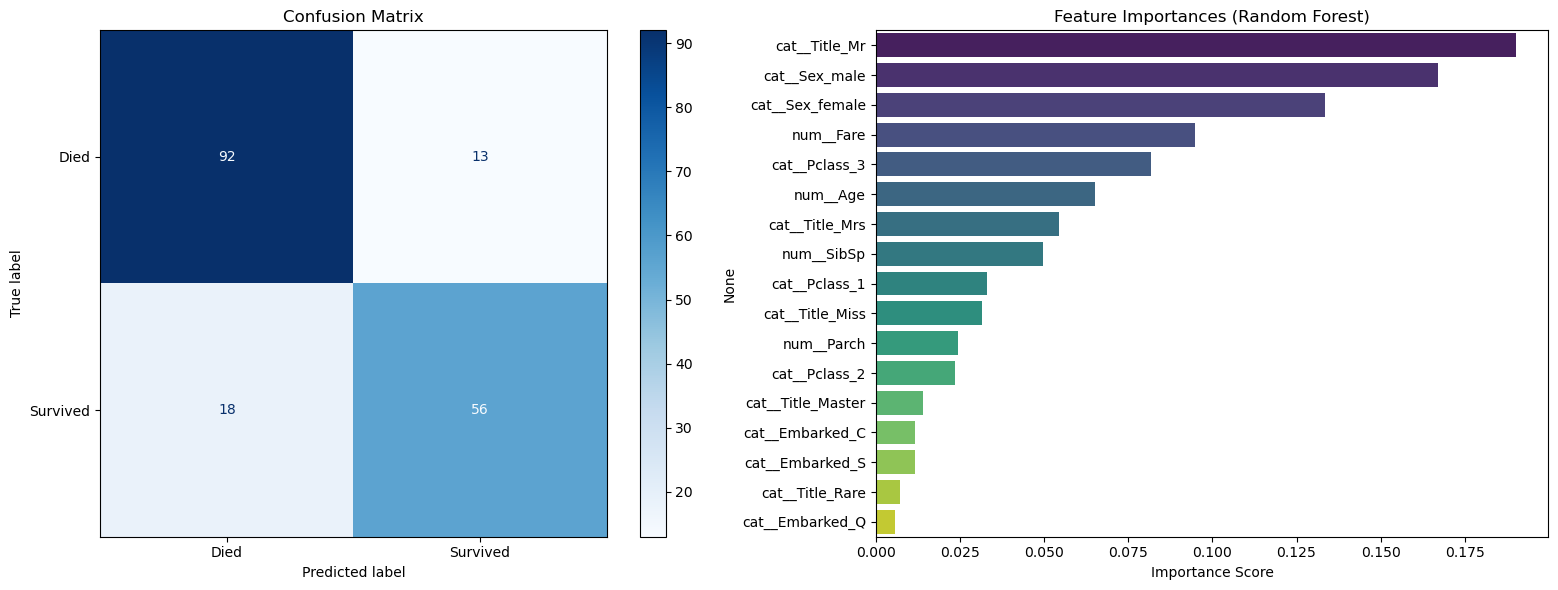

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ... (Previous code for extract_titles, Data Prep, and GridSearchCV remains the same) ...

# 5. Evaluation & Visualizations
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Best CV Score: {grid.best_score_}")
print(classification_report(y_test, y_pred))

# --- NEW VISUALIZATION SECTION ---

# Set up a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Died", "Survived"])
disp.plot(cmap="Blues", ax=ax1)
ax1.set_title("Confusion Matrix")

# 2. Plot Feature Importance
# We need to get the feature names out of the ColumnTransformer
# Note: newer sklearn versions use get_feature_names_out()
try:
    feature_names = best_model.named_steps['prep'].get_feature_names_out()
except AttributeError:
    # Fallback for older versions if needed
    feature_names = numeric_cols + list(best_model.named_steps['prep'].named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(categorical_cols))

importances = best_model.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

sns.barplot(x=feat_imp.values, y=feat_imp.index, ax=ax2, palette="viridis")
ax2.set_title("Feature Importances (Random Forest)")
ax2.set_xlabel("Importance Score")

plt.tight_layout()
plt.show()